# Objective
To transform token level ground truth into clusters

In [1]:
from sklearn.cluster import DBSCAN
import numpy as np
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [31]:
def get_blocks_from_tokens(df, eps=None, min_samples=1):
    all_blocks = []

    LABEL_EPS = {
        'table':     65,
        'caption':   400,
        'paragraph': 40,
        'section':   40,
        'title':     50,
        'abstract':  40,
        'reference': 35,
        'equation':  55,
        'figure':    60,
        'footer':    35,
        'date':      30,
        'author':    40,
        'list':      35,
    }
    DEFAULT_EPS = 40

    # How much to compress vertical distances before clustering.
    # 0.5 means vertical gaps count half as much → easier to merge same-line tokens
    # lower = more horizontally tolerant, higher = treat x/y equally
    LABEL_Y_SCALE = {
        'table':     0.4,   # rows are close, don't want to merge them too aggressively
        'caption':   0.3,   # single line, be very tolerant horizontally
        'paragraph': 0.5,
        'section':   0.5,
        'title':     0.3,
        'equation':  0.3,
    }
    DEFAULT_Y_SCALE = 0.5

    for label in df['label'].unique():
        df_label = df[df['label'] == label].copy()
        if df_label.empty:
            continue

        label_eps     = LABEL_EPS.get(label.lower(), eps if eps is not None else DEFAULT_EPS)
        y_scale       = LABEL_Y_SCALE.get(label.lower(), DEFAULT_Y_SCALE)

        cx = (df_label['x0'] + df_label['x1']) / 2
        cy = (df_label['y0'] + df_label['y1']) / 2

        # Compress Y axis — makes DBSCAN more tolerant of horizontal gaps
        coords = np.column_stack([cx, cy * y_scale])

        clustering = DBSCAN(eps=label_eps, min_samples=min_samples).fit(coords)
        df_label['cluster'] = clustering.labels_

        for cluster_id in set(clustering.labels_):
            if cluster_id == -1:
                continue
            cluster_data = df_label[df_label['cluster'] == cluster_id]
            all_blocks.append({
                'label': label,
                'bbox': [
                    cluster_data['x0'].min(),
                    cluster_data['y0'].min(),
                    cluster_data['x1'].max(),
                    cluster_data['y1'].max()
                ],
                'token_count': len(cluster_data),
                'eps_used': label_eps,
                'y_scale_used': y_scale
            })

    return all_blocks

In [32]:
def visualize_blocks(image, blocks):
    img_w, img_h = image.size

    DOCBANK_SCALE = 1000.0
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(image)
    
    # Definícia farieb pre rôzne labely
    color_map = {
        'caption':   'red',
        'table':     'blue',
        'paragraph': 'green',
        'section':   'orange',
        'figure':    'purple',
        'abstract':  'cyan',
        'reference': 'brown',
        'equation':  'magenta',
        'footer':    'gray',
        'date':      'olive',
        'title':     'darkblue',
        'author':    'teal',
    }

    for block in blocks:
        label = block['label']
        x0, y0, x1, y1 = block['bbox']
        
        # Scale from DocBank 1000-space → image pixel space
        x0_px = x0 / DOCBANK_SCALE * img_w
        y0_px = y0 / DOCBANK_SCALE * img_h
        x1_px = x1 / DOCBANK_SCALE * img_w
        y1_px = y1 / DOCBANK_SCALE * img_h
        
        color = color_map.get(label.lower(), 'black')
        width  = x1_px - x0_px
        height = y1_px - y0_px
        
        rect = patches.Rectangle(
            (x0_px, y0_px), width, height,
            linewidth=2,
            edgecolor=color,
            facecolor='none',
            alpha=0.8
        )
        ax.add_patch(rect)
        ax.text(
            x0_px, y0_px - 2,
            f"{label} ({block['token_count']})",
            color=color,
            fontsize=8,
            fontweight='bold',
            backgroundcolor='white'
        )
    
    plt.title(f"DBSCAN Blocks (Total: {len(blocks)})")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

Obrázok načítaný: (773, 1000)


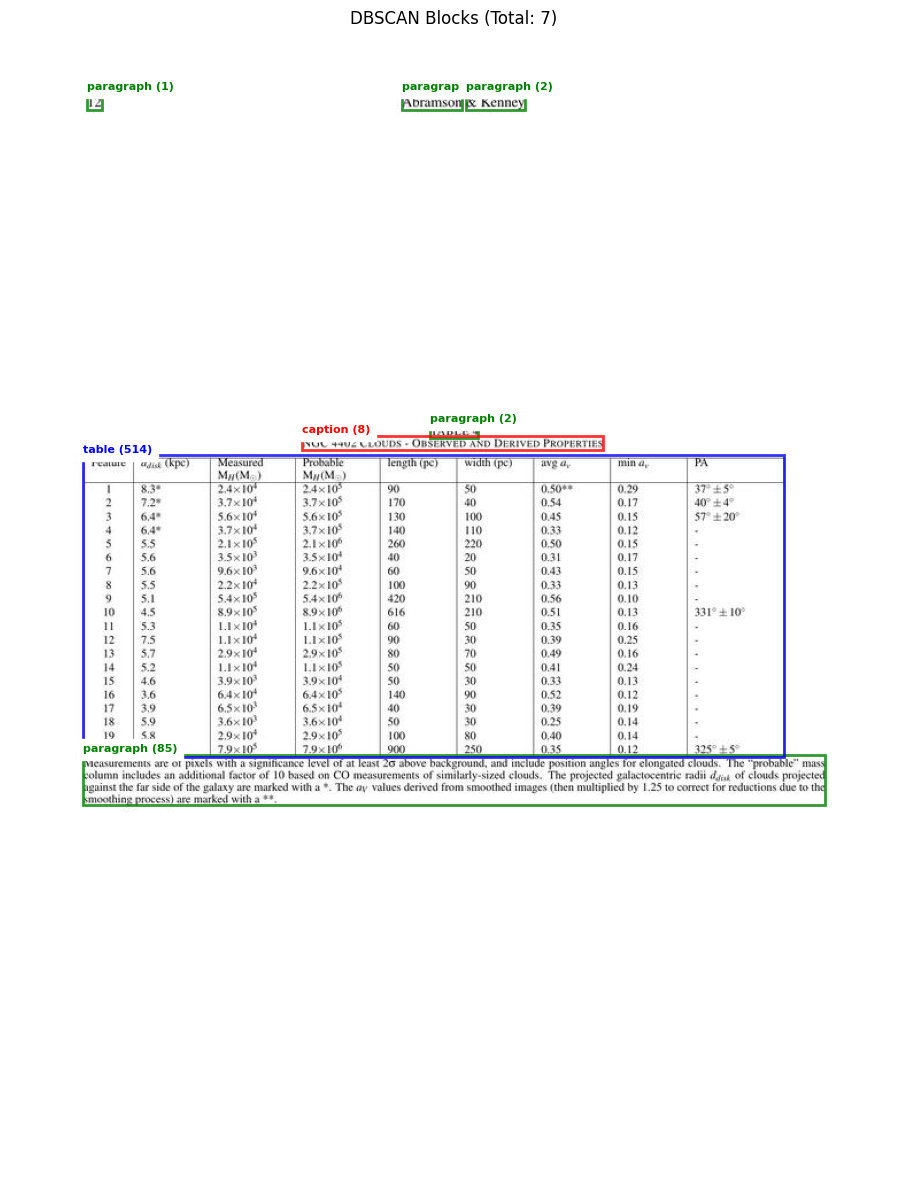

In [33]:
DOCBANK_DIR = 'data/DocBank/DocBank_500K_txt'

test_file_txt = 'data/DocBank/DocBank_500K_txt/1.tar_1401.0023.gz_abramson2013-emulateapj-12-30_11.txt'
test_file_jpg = 'data/DocBank/DocBank_500K_ori_img/1.tar_1401.0023.gz_abramson2013-emulateapj-12-30_11_ori.jpg'

# '1.tar_1401.0023.gz_abramson2013-emulateapj-12-30_5_ori.jpg'
# '1.tar_1401.0033.gz_trabalho_um_minos_1_ori.jpg'

# Load image
img = Image.open(test_file_jpg)
print(f"Obrázok načítaný: {img.size}")

# Load ground truth
columns = ['token', 'x0', 'y0', 'x1', 'y1', 'r', 'g', 'b', 'font', 'label']
df = pd.read_csv(test_file_txt, sep='\t', names=columns, quoting=3) # quoting=3 ignoruje úvodzovky v texte
#print(df.head()) # Zobrazí prvých 5 riadkov


# Do clustering for txt ground truth - DB scan
cluster_blocks = get_blocks_from_tokens(df)

#print(cluster_blocks)
# Display ground truth onto image
visualize_blocks(img, cluster_blocks)